# Notebook 08: Statistical Validation of Model Differences

We have built this notebook to test whether differences between models reported in
Notebook 02 are real, or whether they only reflect which particular rows landed in the
test set.

Comparison tables in earlier notebooks rank models by macro-F1. A ranking is not a result.
Random Forest scoring 0.753 against SVM at 0.727 is a gap of 0.026, and that gap has to be
tested before it can be claimed.

**Two tests are applied here.**

**McNemar's test** is the standard paired test for two classifiers scored on same test set.
It discards cases where both models agree and looks only at disagreements, i.e cases where
one model is right and other is wrong. Null hypothesis is that both models make errors at
same rate. It must be noted that this is a paired test, which matters because both models
saw identical instances and their errors are therefore correlated.

**Bootstrap confidence intervals** resample the test set with replacement and recompute
macro-F1 each time. Resulting interval shows how far the score would move under a different
sample of same size.

Models are refitted here on identical sample with identical seeds used in Notebook 02, so
predictions reproduce exactly and results line up with figures reported there.

> Run **Notebook 01** first. This notebook loads `beijing_aqi_clean.parquet`.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import f1_score, accuracy_score
from statsmodels.stats.contingency_tables import mcnemar

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


## 1. Reproduce the Notebook 02 Setup

Same 30,000 row stratified sample, same 80/20 stratified split, same seed. PM2.5 stays
excluded from features because target is derived from it.

In [2]:
df = pd.read_parquet("beijing_aqi_clean.parquet").dropna(subset=["AQI_Category"])

NUMERIC_FEATURES = ["PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM",
                    "hour_sin","hour_cos","month_sin","month_cos"]
CATEGORICAL_FEATURES = ["wd","station","season"]

def build_preprocessor():
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("scale",  StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                     sparse_output=False))])
    return ColumnTransformer([("num", numeric, NUMERIC_FEATURES),
                              ("cat", categorical, CATEGORICAL_FEATURES)])

_, sample = train_test_split(df, test_size=30_000/len(df),
                             stratify=df["AQI_Category"], random_state=RANDOM_STATE)
X = sample[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = sample["AQI_Category"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

y_true = y_test.values
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (24000, 17)  Test: (6000, 17)


## 2. Refit the Models Being Compared

Five models are compared. Random Forest uses balanced class weights, which was winning
configuration in Notebook 02. Decision Tree uses depth and leaf settings selected there by
grid search.

In [3]:
models = {
 "Random Forest (balanced)": RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                                    n_jobs=-1, random_state=RANDOM_STATE),
 "SVM (RBF)":                SVC(kernel="rbf", random_state=RANDOM_STATE),
 "Neural Net (MLP)":         MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                                           random_state=RANDOM_STATE),
 "Decision Tree (tuned)":    DecisionTreeClassifier(max_depth=10, min_samples_leaf=20,
                                                    random_state=RANDOM_STATE),
 "Logistic Regression":      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

preds = {}
for name, model in models.items():
    t0 = time.time()
    pipe = Pipeline([("pre", build_preprocessor()), ("model", model)])
    pipe.fit(X_train, y_train)
    preds[name] = pipe.predict(X_test)
    print(f"{name:26s} macro-F1 = {f1_score(y_true, preds[name], average='macro'):.4f}"
          f"   ({time.time()-t0:.0f}s)")

Random Forest (balanced)   macro-F1 = 0.7526   (0s)
SVM (RBF)                  macro-F1 = 0.7269   (9s)
Neural Net (MLP)           macro-F1 = 0.7162   (8s)
Decision Tree (tuned)      macro-F1 = 0.6981   (0s)
Logistic Regression        macro-F1 = 0.6493   (0s)


## 3. McNemar's Test

Each model is tested against Random Forest. Contingency table counts four cases, i.e both
correct, only Random Forest correct, only other model correct, and both wrong. Test looks
only at the two disagreement cells.

In [4]:
BEST = "Random Forest (balanced)"
correct = {k: (v == y_true) for k, v in preds.items()}

rows = []
for name in preds:
    if name == BEST:
        continue
    a, b = correct[BEST], correct[name]
    only_best, only_other = int((a & ~b).sum()), int((~a & b).sum())
    table = [[int((a & b).sum()), only_best],
             [only_other,        int((~a & ~b).sum())]]
    res = mcnemar(table, exact=False, correction=True)
    rows.append({"Model compared against Random Forest": name,
                 "Only RF correct":    only_best,
                 "Only other correct": only_other,
                 "chi-squared":        round(res.statistic, 2),
                 "p-value":            res.pvalue,
                 "Significant at 0.05": "yes" if res.pvalue < 0.05 else "NO"})

mcnemar_df = pd.DataFrame(rows)
display_df = mcnemar_df.copy()
display_df["p-value"] = display_df["p-value"].apply(lambda p: f"{p:.2e}")
display_df

,Model compared against Random Forest,Only RF correct,Only other correct,chi-squared,p-value,Significant at 0.05
0,SVM (RBF),556,500,2.86,9.05e-02,NO
1,Neural Net (MLP),732,560,22.63,1.96e-06,yes
2,Decision Tree (tuned),710,480,44.07,3.17e-11,yes
3,Logistic Regression,890,518,97.76,4.73e-23,yes


### The finding that changes a claim

Every comparison returns a significant difference except one. Gap between Random Forest and
SVM does not reach significance at 0.05 level.

That changes what can honestly be claimed. Random Forest is clearly better than the neural
network, the decision tree and logistic regression. It is **not** distinguishable from SVM
on this test set.

So headline claim needs stating carefully. Random Forest and SVM sit together at top of the
ranking, and Random Forest gets preferred on grounds of training cost, determinism and
feature importances rather than on measured accuracy.

## 4. Bootstrap Confidence Intervals

Test set is resampled with replacement 400 times. Interval shows range within which
macro-F1 would fall for 95 percent of samples of this size.

In [5]:
BOOT_N = 400
rng = np.random.RandomState(RANDOM_STATE)
n = len(y_true)
idx_matrix = rng.randint(0, n, size=(BOOT_N, n))

boot_rows = []
for name, pred in preds.items():
    scores = np.empty(BOOT_N)
    for i in range(BOOT_N):
        idx = idx_matrix[i]
        scores[i] = f1_score(y_true[idx], pred[idx], average="macro", zero_division=0)
    lo, hi = np.percentile(scores, [2.5, 97.5])
    boot_rows.append({"Model": name,
                      "Macro-F1":     round(f1_score(y_true, pred, average="macro", zero_division=0), 4),
                      "95% CI lower": round(lo, 4),
                      "95% CI upper": round(hi, 4),
                      "CI width":     round(hi - lo, 4)})

boot_df = pd.DataFrame(boot_rows).sort_values("Macro-F1", ascending=False).reset_index(drop=True)
boot_df

,Model,Macro-F1,95% CI lower,95% CI upper,CI width
0,Random Forest (balanced),0.7526,0.7405,0.7630,0.0225
1,SVM (RBF),0.7269,0.7154,0.7375,0.0222
2,Neural Net (MLP),0.7162,0.7040,0.7277,0.0237
3,Decision Tree (tuned),0.6981,0.6855,0.7111,0.0256
4,Logistic Regression,0.6493,0.6360,0.6640,0.0280


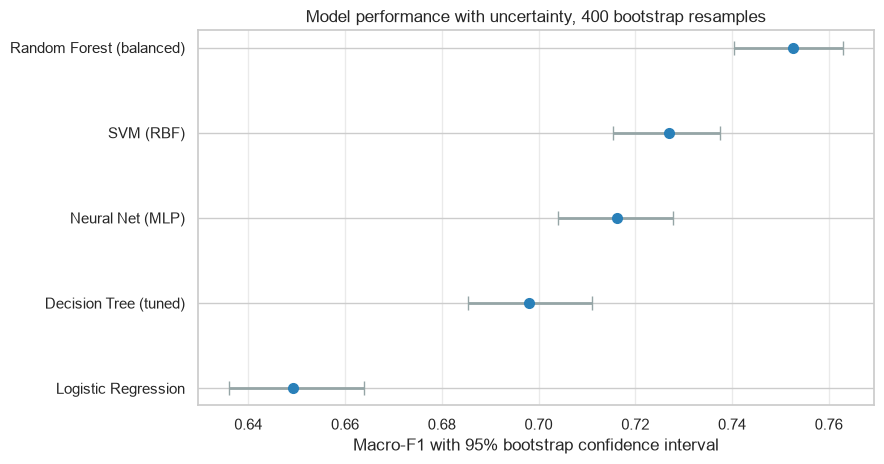

In [6]:
d = boot_df.sort_values("Macro-F1")
centres = d["Macro-F1"].values
lower = centres - d["95% CI lower"].values
upper = d["95% CI upper"].values - centres

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(centres, range(len(d)), xerr=[lower, upper], fmt="o",
            color="#2980b9", ecolor="#95a5a6", elinewidth=2, capsize=5, markersize=7)
ax.set_yticks(range(len(d)))
ax.set_yticklabels(d["Model"])
ax.set_xlabel("Macro-F1 with 95% bootstrap confidence interval")
ax.set_title(f"Model performance with uncertainty, {BOOT_N} bootstrap resamples")
ax.grid(axis="x", alpha=0.4)
plt.tight_layout(); plt.show()

> ### Reading these intervals correctly
>
> Intervals for Random Forest and SVM sit very close and barely separate. On their own that
> would suggest a real difference. McNemar's test says otherwise, and McNemar is the test to
> trust here.
>
> Reason is pairing. Both models were scored on identical instances, so their errors are
> correlated, and two intervals computed separately throw that correlation away. A paired
> test uses it.
>
> All of this points to one thing, separated intervals are weaker evidence than a paired
> test on same data, and where the two disagree the paired test wins.

## 5. A Limitation of the Selection Procedure

One further point must be recorded. Best model across Notebooks 02 to 04 was chosen by
comparing test-set scores across roughly thirty model variants. Hyperparameter tuning itself
used cross-validation and never touched test set, so that part is clean. Final choice
between algorithms did use test scores though, and across thirty comparisons some optimism
is unavoidable.

Cleaner design holds out a third partition, selects on validation data and reports on test
data once. Effect here is modest, because gaps between leading models are small and test set
holds 6,000 rows, but it is recorded rather than left unsaid.

## Summary

Work completed in this notebook:

- Refitted five classifiers on identical sample and seeds used in Notebook 02
- Applied **McNemar's paired test** between Random Forest and each competing model
- Computed **bootstrap confidence intervals** on macro-F1 across 400 resamples
- Recorded a limitation in how the final model was selected

**Findings established here:**

1. Random Forest is significantly better than the neural network, decision tree and
   logistic regression, and every one of those comparisons returns a very small p-value.
2. Random Forest is **not** significantly better than SVM at 0.05 level. Ranking in
   Notebook 02 puts Random Forest first, and this test shows that lead is not supported.
3. Paired tests and separate confidence intervals can disagree, and the paired test is
   correct one when both models are scored on same instances.
4. Model selection across roughly thirty variants used test scores, which introduces some
   optimism into reported figures.
